In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from itertools import product
from collections import defaultdict

In [3]:
data = pd.read_csv('data.csv')
data.head()

,Date,SPY,QQQ,IWM,TLT,GLD,SLV,EURUSD=X
0,2023-01-03,366.069092,259.795929,166.989792,90.171211,171.059998,22.049999,1.067771
1,2023-01-04,368.895172,261.033600,169.069962,91.406570,172.669998,21.889999,1.054685
2,2023-01-05,364.684845,256.947205,167.259415,91.788696,170.520004,21.389999,1.060637
3,2023-01-06,373.047821,264.039368,171.015259,93.477318,173.710007,21.920000,1.052222
4,2023-01-09,372.836365,265.748535,171.304169,93.975014,174.100006,21.740000,1.065632


In [4]:
data.describe()

,SPY,QQQ,IWM,TLT,GLD,SLV,EURUSD=X
count,766.000000,766.000000,766.000000,766.000000,766.000000,766.000000,766.000000
mean,523.538468,453.023783,203.209955,87.607693,243.279687,28.930757,1.099542
std,93.248136,96.692229,24.945875,3.996025,68.530656,10.995881,0.039671
min,364.684845,256.947205,157.962006,75.373993,168.350006,18.400000,1.024443
25%,433.058487,368.700935,182.097176,85.019207,184.292500,21.760000,1.073344
50%,531.427368,457.119141,200.519440,87.379890,221.474998,26.700000,1.088566
75%,592.402710,520.093628,220.231125,90.327950,297.699997,30.219999,1.122861
max,695.159973,634.951965,269.790009,97.186768,458.000000,92.910004,1.187141


<Axes: >

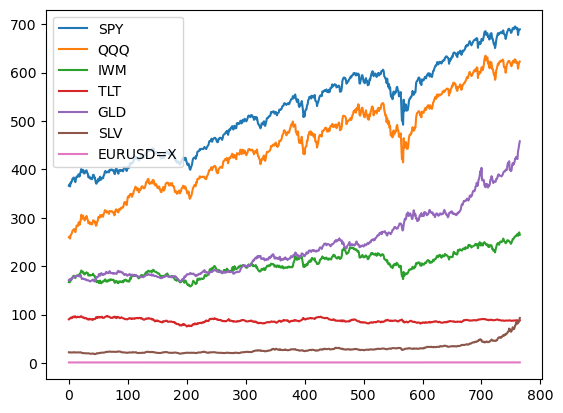

In [5]:
data.plot()

In [11]:
data = data.dropna()
data.tail(0)

,Date,SPY,QQQ,IWM,TLT,GLD,SLV,EURUSD=X


In [18]:
spy = np.log(data['SPY']).diff()
tlt = np.log(data['TLT']).diff()
gld  =  np.log(data['GLD']).diff()
eur = np.log(data['EURUSD=X']).diff()
log = pd.DataFrame({'spy': spy, 'tlt': tlt, 'gld': gld, 'eur': eur })
log.dropna()

,spy,tlt,gld,eur
1,0.007690,0.013607,0.009368,-0.012331
2,-0.011479,0.004172,-0.012530,0.005627
3,0.022673,0.018230,0.018535,-0.007965
4,-0.000567,0.005310,0.002243,0.012664
5,0.006988,-0.016689,0.003669,0.007187
...,...,...,...,...
761,-0.000838,-0.005792,-0.004831,-0.003209
762,-0.020567,-0.013185,0.037138,0.002592
763,0.011475,0.007588,0.014464,0.007594
764,0.005210,0.004343,0.018294,-0.004692


In [19]:
log.describe()

,spy,tlt,gld,eur
count,765.000000,765.000000,765.000000,765.000000
mean,0.000827,-0.000033,0.001287,0.000126
std,0.009506,0.009412,0.010358,0.004573
min,-0.060327,-0.030620,-0.066427,-0.018590
25%,-0.003252,-0.006114,-0.004464,-0.002533
50%,0.001042,0.000437,0.001221,-0.000153
75%,0.005926,0.005747,0.007228,0.002875
max,0.099863,0.033905,0.037138,0.027537


In [38]:

log = log.dropna()

for col in log.columns:
    result = adfuller(log[col], autolag='BIC')

    print(f"\nADF Test Results for {col.upper()}")
    print(f"Test Statistic        : {result[0]:.6f}")
    print(f"P-value               : {result[1]:.6f}")
    print(f"Number of lags        : {result[2]}")
    print(f"Number of observations: {result[3]}")

    for key, value in result[4].items():
        print(f"Critical value {key}: {value:.6f}")

    if result[1] < 0.05:
        print("Conclusion: Stationary (reject H0)")
    else:
        print("Conclusion: Non-stationary (fail to reject H0)")



ADF Test Results for SPY
Test Statistic        : -29.203794
P-value               : 0.000000
Number of lags        : 0
Number of observations: 764
Critical value 1%: -3.438938
Critical value 5%: -2.865330
Critical value 10%: -2.568788
Conclusion: Stationary (reject H0)

ADF Test Results for TLT
Test Statistic        : -29.221747
P-value               : 0.000000
Number of lags        : 0
Number of observations: 764
Critical value 1%: -3.438938
Critical value 5%: -2.865330
Critical value 10%: -2.568788
Conclusion: Stationary (reject H0)

ADF Test Results for GLD
Test Statistic        : -28.710276
P-value               : 0.000000
Number of lags        : 0
Number of observations: 764
Critical value 1%: -3.438938
Critical value 5%: -2.865330
Critical value 10%: -2.568788
Conclusion: Stationary (reject H0)

ADF Test Results for EUR
Test Statistic        : -28.703392
P-value               : 0.000000
Number of lags        : 0
Number of observations: 764
Critical value 1%: -3.438938
Critical v

In [40]:
lagged = log.shift(1)
combined = log.join(lagged, rsuffix = '_lag1').dropna()
combined.head()

,spy,tlt,gld,eur,spy_lag1,tlt_lag1,gld_lag1,eur_lag1
2,-0.011479,0.004172,-0.012530,0.005627,0.007690,0.013607,0.009368,-0.012331
3,0.022673,0.018230,0.018535,-0.007965,-0.011479,0.004172,-0.012530,0.005627
4,-0.000567,0.005310,0.002243,0.012664,0.022673,0.018230,0.018535,-0.007965
5,0.006988,-0.016689,0.003669,0.007187,-0.000567,0.005310,0.002243,0.012664
6,0.012569,0.016121,-0.000687,0.000537,0.006988,-0.016689,0.003669,0.007187


In [44]:
def symbolic_states(
    returns: pd.DataFrame,
    window: int = 252
) -> pd.DataFrame:

    states = pd.DataFrame(index=returns.index, columns=returns.columns)

    for col in returns.columns:
        rolling = returns[col].rolling(window)

        q33 = rolling.quantile(0.33)
        q67 = rolling.quantile(0.67)

        states[col] = np.where(
            returns[col] < q33, -1,
            np.where(returns[col] > q67, 1, 0)
        )

    states = states.iloc[window:]
    return states.astype(int)


In [55]:
symbolic_states(combined)

,spy,tlt,gld,eur,spy_lag1,tlt_lag1,gld_lag1,eur_lag1
254,1,1,-1,0,0,-1,0,0
255,0,-1,0,0,1,1,-1,0
256,1,0,0,0,0,-1,0,0
257,0,1,0,1,1,0,0,0
258,0,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...
761,0,-1,-1,-1,0,0,-1,0
762,-1,-1,1,1,0,-1,-1,-1
763,1,1,1,1,-1,-1,1,1
764,1,1,1,-1,1,1,1,1


In [45]:
def lag_symbolic_states(states: pd.DataFrame):
    
    current = states.iloc[1:].copy()
    lagged = states.shift(1).iloc[1:].copy()
    return current, lagged


In [54]:
lag_symbolic_states(symbolic_states(log))

(     spy  tlt  gld  eur
 254    1    1   -1    0
 255    0   -1    0    0
 256    1    0    0    0
 257    0    1    0    1
 258    0    0    1    0
 ..   ...  ...  ...  ...
 761    0   -1   -1   -1
 762   -1   -1    1    1
 763    1    1    1    1
 764    1    1    1   -1
 765    0    0    1    1
 
 [512 rows x 4 columns],
      spy  tlt  gld  eur
 254  0.0 -1.0  0.0  0.0
 255  1.0  1.0 -1.0  0.0
 256  0.0 -1.0  0.0  0.0
 257  1.0  0.0  0.0  0.0
 258  0.0  1.0  0.0  1.0
 ..   ...  ...  ...  ...
 761  0.0  0.0 -1.0  0.0
 762  0.0 -1.0 -1.0 -1.0
 763 -1.0 -1.0  1.0  1.0
 764  1.0  1.0  1.0  1.0
 765  1.0  1.0  1.0 -1.0
 
 [512 rows x 4 columns])

In [46]:
def joint_counts(y_t, y_lag, x_lag):

    counts = defaultdict(int)

    for yt, yl, xl in zip(y_t, y_lag, x_lag):
        counts[(yt, yl, xl)] += 1

    return counts


In [47]:
def normalize_counts(counts):
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}


In [48]:
def transfer_entropy(y_t, y_lag, x_lag):
    
    joint_xyz = joint_counts(y_t, y_lag, x_lag)
    p_xyz = normalize_counts(joint_xyz)

    # Marginals
    p_yz = defaultdict(float)
    p_yy = defaultdict(float)
    p_y = defaultdict(float)

    for (yt, yl, xl), p in p_xyz.items():
        p_yz[(yl, xl)] += p
        p_yy[(yt, yl)] += p
        p_y[yl] += p

    te = 0.0
    for (yt, yl, xl), p in p_xyz.items():
        if p == 0:
            continue

        p1 = p / p_yz[(yl, xl)]
        p2 = p_yy[(yt, yl)] / p_y[yl]

        te += p * np.log(p1 / p2)

    return te


In [49]:
def rolling_te(states, window=252):
    assets = states.columns
    results = []

    for start in range(len(states) - window):
        end = start + window
        window_states = states.iloc[start:end]

        current, lagged = lag_symbolic_states(window_states)

        te_matrix = pd.DataFrame(
            0.0, index=assets, columns=assets
        )

        for x in assets:
            for y in assets:
                if x == y:
                    continue

                te_matrix.loc[x, y] = transfer_entropy(
                    current[y],
                    lagged[y],
                    lagged[x]
                )

        results.append(te_matrix)

    return results


In [50]:
def permutation_te(y_t, y_lag, x_lag, n_perm=500):
    null = []

    for _ in range(n_perm):
        shuffled = np.random.permutation(x_lag)
        null.append(transfer_entropy(y_t, y_lag, shuffled))

    return np.mean(null), np.std(null)


In [51]:
def te_zscore(te_obs, mu, sigma):
    if sigma == 0:
        return 0.0
    return (te_obs - mu) / sigma
